# Laboratorio de regresión - 5

|                |   |
:----------------|---|
| **Nombre**     |Juan Pablo Moran    |
| **Fecha**      21 de sep   |
| **Expediente** 753760|   |

## Validación

Hemos estado usando `train_test_split` en nuestros modelos anteriores.

¿Por qué?

- Porque si evaluamos el modelo con los mismos datos con los que lo entrenamos, el error sale muy optimista: el modelo ya "vio" esas observaciones y puede estar memorizandolas (overfitting). Al separar una parte de los datos para prueba (test) que el modelo nunca vio al entrenar, podemos medir que tan bien predice datos nuevos, es decir, que tan bien generaliza. Asi podemos detectar si el modelo esta sobreajustado y comparar modelos de forma justa.

Si la muestra es un subset de la población y queremos generalizar sobre la población, ¿no sería mejor utilizar todos los datos al entrenar un modelo?

- En parte si: entre mas datos tenga el modelo para entrenar, mejor puede estimar los coeficientes y menor es la varianza de las estimaciones. El problema es que si usamos todos los datos para entrenar ya no nos queda ningun dato "nuevo" para medir que tan bien generaliza el modelo, y no sabriamos si esta haciendo overfitting. Por eso primero se separan los datos para validar el modelo y, una vez que vemos que generaliza bien, se puede volver a entrenar con el dataset completo para el modelo final.

El propósito de volver a muestrear dentro de nuestro dataset es tener una idea de qué tan buena podría ser la generalización de nuestro modelo. Imagina un dataset ya separado en dos mitades. Utilizas la primera mitad para entrenar el modelo y pruebas en la segunda mitad; la segunda mitad eran datos invisibles para el modelo al momento de entrenar. Esto nos lleva a tres escenario típicos:

1. Si el modelo hace buenas predicciones en la segunda mitad, significa que la primera mitad era "suficiente" para generalizar.
2. Si el modelo no hace buenas predicciones en la segunda mitad, pero sí en la primera mitad, podría ser que había información importante en la segunda mitad que debió haber sido tomada en cuenta al entrenar, o un problema de overfitting.
3. Si el modelo no hace buenas predicciones en la segunda mitad, y tampoco en la primera mitad, se tendrían que revisar los factores y/o el modelo seleccionado.

El caso ideal sería el 1, pero por estadística los errores y varianzas tienen como entrada el número de muestas, por lo que tenemos menos seguridad de nuestros resutados al usar menos muestras. Si vemos que el modelo generaliza bien podemos unir de nuevo el dataset y entrenar sobre el dataset completo.

En el caso 2 está el problema de que no podemos saber qué información es necesaria para el entrenamiento apropiado del modelo; esto nos lleva a pensar que debemos usar el dataset completo para entrenar, pero esto nos lleva al mismo problema de no saber si el modelo puede generalizar.

El problema sólo incrementa si se tienen hiperparámetros en el modelo (e.g. $\lambda$ en regularización).

## Leave-One-Out Cross Validation

Este método de validación es una colección de $n$ `train-test-split`. Teniendo un dataset de $n$ muestras, la lógica es:
1. Saca una muestra del dataset.
2. Entrena tu modelo con las $n-1$ muestras.
3. Evalúa tu modelo en la muestra que quedó fuera con el métrico que más se ajuste a la aplicación.
4. Regresa la muestra al dataset.
5. Repite 1-4 con muestras diferentes hasta haber hecho el procedimiento $n$ veces para $n$ muestras.
6. Calcula la media y desviación estándar de los métricos guardados.

Con los resultados del proceso de validación podemos saber qué tan bueno podría ser el modelo seleccionado con los datos (con/sin transformaciones).

### Ejercicio 1

Utiliza el dataset `Motor Trend Car Road Tests`. Elimina la columna `model` y entrena 32 modelos diferentes utilizando Leave-One-Out Cross Validation con target `mpg`. Utiliza MSE como métrico.

In [2]:
import pandas as pd

df = pd.read_excel("Motor Trend Car Road Tests.xlsx")
df = df[["mpg", "cyl", "disp", "hp", "drat", "wt", "qsec", "vs", "am", "gear", "carb"]]
print(df.shape)
df.head()

(32, 11)


,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


In [3]:
from sklearn.model_selection import LeaveOneOut
from sklearn.linear_model import LinearRegression
import numpy as np

X = df[["cyl", "disp", "hp", "drat", "wt", "qsec", "vs", "am", "gear", "carb"]]
Y = df["mpg"]

loo = LeaveOneOut()
mse_lista = []

for train_index, test_index in loo.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    Y_train, Y_test = Y.iloc[train_index], Y.iloc[test_index]

    lr = LinearRegression()
    lr.fit(X_train, Y_train)
    y_pred = lr.predict(X_test)
    mse = np.sum((Y_test - y_pred)**2) / len(Y_test)
    mse_lista.append(mse)

resultados = pd.Series(mse_lista)
print("Numero de modelos:", len(mse_lista))
resultados.describe()

Numero de modelos: 32


count    32.000000
mean     12.181558
std      17.340496
min       0.000103
25%       0.990079
50%       6.041350
75%      15.106113
max      83.114576
dtype: float64

In [4]:
lr = LinearRegression()
lr.fit(X, Y)
y_pred = lr.predict(X)
residuos = Y - y_pred
print("MSE entrenando y evaluando con todos los datos:", np.sum(residuos**2) / len(Y))
print("R2 con todos los datos:", lr.score(X, Y))
print("RMSE de LOOCV:", np.sqrt(resultados.mean()))
Y.describe()

MSE entrenando y evaluando con todos los datos: 4.609200938020335
R2 con todos los datos: 0.8690157644777646
RMSE de LOOCV: 3.490208877259635


count    32.000000
mean     20.090625
std       6.026948
min      10.400000
25%      15.425000
50%      19.200000
75%      22.800000
max      33.900000
Name: mpg, dtype: float64

Text(0, 0.5, 'MSE')

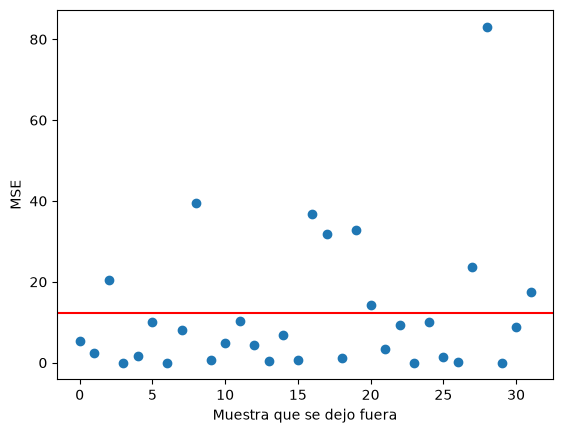

In [5]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(range(len(mse_lista)), mse_lista)
plt.axhline(resultados.mean(), color="red")
plt.xlabel("Muestra que se dejo fuera")
plt.ylabel("MSE")

Interpreta.

- Se entrenaron 32 modelos de regresion multiple (uno por cada auto que se deja fuera) y el MSE promedio fue de aprox. 12.18, es decir un error tipico (RMSE) de unas 3.5 mpg al predecir un auto que el modelo no vio. Como la desviacion estandar de mpg es de aprox. 6 mpg, el modelo si reduce el error, pero no es un error despreciable.
- Si entrenamos y evaluamos con los mismos 32 autos el MSE es de solo aprox. 4.6 (R2 de aprox. 0.87), casi 3 veces menor que el de LOOCV. Esto muestra que el error en entrenamiento es muy optimista y que el modelo tiene algo de overfitting: con 10 factores y solo 32 muestras el modelo se ajusta demasiado a los datos con los que entrena.
- La desviacion estandar del MSE (aprox. 17) es mayor que la media, o sea que el error cambia mucho dependiendo del auto que se deja fuera. En la grafica se ve que la mayoria de los autos tienen un MSE bajo (la mediana es de aprox. 6), pero unos pocos como el Ford Pantera L (MSE de aprox. 83), el Merc 230 o el Chrysler Imperial tienen errores muy grandes y jalan el promedio hacia arriba. Estos autos son "raros" respecto al resto, y cuando se dejan fuera el modelo no tiene informacion parecida para predecirlos.
- En conclusion, el modelo con todos los factores generaliza de forma regular; probablemente convendria quitar factores poco significativos o usar penalizacion (Ridge/Lasso) para reducir la varianza.

## K-Folds Cross-Validation

El dataset `Motor Trend Car Road Tests` sólo tiene 32 muestras, y utilizar un modelo sencillo de regresión múltiple hace que usar LOOCV sea muy rápido. El dataset `California Housing` tiene $20640$ muestras para $9$ columnas, entonces realizar un ajuste sobre una transformación o sobre el modelo y luego calcular el impacto esperado podría tomar más tiempo.

La solución propuesta es dividir el dataset en *k* folds (partes iguales), ajustar en *k-1* folds y probar en el restante.

### Ejercicio 2
Utiliza el dataset `California Housing` y haz K-folds Cross Validation con 10 folds. Utiliza el MSE como métrico.

In [6]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()
print("Dataset Shape:", housing.data.shape, housing.target.shape)
print("Dataset Features:", housing.feature_names)
print("Dataset Target:", housing.target_names)
X = housing.data
y = housing.target

Dataset Shape: (20640, 8) (20640,)
Dataset Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Dataset Target: ['MedHouseVal']


In [7]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=10, shuffle=True, random_state=0)
mse_lista2 = []

for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    Y_train, Y_test = y[train_index], y[test_index]

    lr = LinearRegression()
    lr.fit(X_train, Y_train)
    y_pred = lr.predict(X_test)
    mse = np.sum((Y_test - y_pred)**2) / len(Y_test)
    mse_lista2.append(mse)

resultados2 = pd.Series(mse_lista2)
resultados2.describe()

count    10.000000
mean      0.527930
std       0.024745
min       0.478051
25%       0.515619
50%       0.528298
75%       0.537199
max       0.569268
dtype: float64

In [8]:
lr = LinearRegression()
lr.fit(X, y)
y_pred = lr.predict(X)
residuos = y - y_pred
print("MSE entrenando y evaluando con todos los datos:", np.sum(residuos**2) / len(y))
print("R2 con todos los datos:", lr.score(X, y))
print("RMSE de K-Folds:", np.sqrt(resultados2.mean()))
pd.Series(y).describe()

MSE entrenando y evaluando con todos los datos: 0.5243209861846072
R2 con todos los datos: 0.606232685199805
RMSE de K-Folds: 0.7265878652823032


count    20640.000000
mean         2.068558
std          1.153956
min          0.149990
25%          1.196000
50%          1.797000
75%          2.647250
max          5.000010
dtype: float64

Text(0, 0.5, 'MSE')

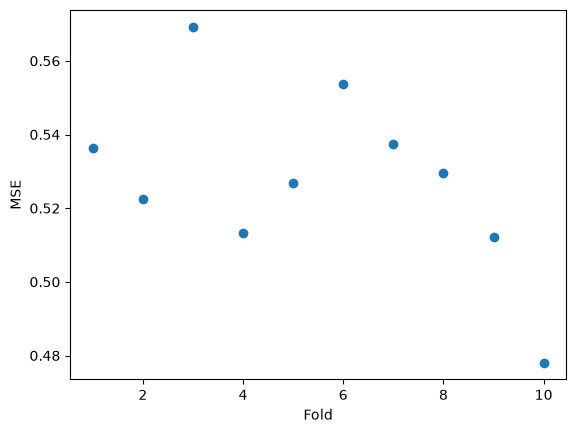

In [10]:
plt.figure()
plt.scatter(range(1, 11), mse_lista2)
plt.xlabel("Fold")
plt.ylabel("MSE")

Interpreta.

- Con 10 folds se entrenaron 10 modelos, cada uno con el 90% de los datos, y el MSE promedio en los folds de prueba fue de aprox. 0.53 (RMSE de aprox. 0.73, y como el target esta en unidades de 100,000 dolares, el error tipico es de unos 73,000 dolares en el valor medio de las casas).
- La desviacion estandar del MSE es muy chica (aprox. 0.02) y todos los folds dan valores parecidos (entre aprox. 0.48 y 0.57). Esto indica que el modelo es estable: no importa que parte de los datos se use para probar, el error es casi el mismo, gracias a que hay muchas muestras (20640).
- El MSE entrenando con todos los datos (aprox. 0.525) es practicamente igual al de validacion, asi que no hay overfitting; el modelo generaliza bien. Sin embargo, el R2 es de solo aprox. 0.61 y el RMSE (0.73) no esta tan lejos de la desviacion estandar del target (aprox. 1.15), por lo que el problema es mas de sesgo: una regresion lineal con estos factores se queda corta y se podrian probar transformaciones o terminos no lineales.
- A diferencia de LOOCV, que aqui requeriria entrenar 20640 modelos, K-Folds da una estimacion confiable del error con solo 10 ajustes.

## Referencia

James, G., Witten, D., Hastie, T., Tibshirani, R.,, Taylor, J. (2023). An Introduction to Statistical Learning with Applications in Python. Cham: Springer. ISBN: 978-3-031-38746-3